# Mumbai House Price Prediction

**Objective:** Predict house prices in Mumbai using Linear Regression.

### Tasks
1. Collect a house price dataset (area, number of rooms, location)
2. Perform data cleaning and preprocessing
3. Analyze factors affecting house prices
4. Implement a Linear Regression model
5. Train the model using the dataset
6. Predict house prices
7. Evaluate the model using Mean Squared Error (MSE)
8. Visualize actual vs predicted house prices

## Task 1 - Import Libraries & Load Dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load the dataset
df = pd.read_csv('Mumbai House Prices.csv')
print(f'Dataset shape: {df.shape}')
print(f'Total records: {df.shape[0]:,}  |  Total features: {df.shape[1]}')
df.head()

Dataset shape: (76038, 9)
Total records: 76,038  |  Total features: 9


,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [6]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bhk         76038 non-null  int64  
 1   type        76038 non-null  object 
 2   locality    76038 non-null  object 
 3   area        76038 non-null  int64  
 4   price       76038 non-null  float64
 5   price_unit  76038 non-null  object 
 6   region      76038 non-null  object 
 7   status      76038 non-null  object 
 8   age         76038 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.2+ MB


In [7]:
df.describe()

,bhk,area,price
count,76038.000000,76038.000000,76038.00000
mean,2.015111,1024.536850,29.38227
std,0.922754,670.276165,32.90345
min,1.000000,127.000000,1.00000
25%,1.000000,640.000000,1.75000
50%,2.000000,872.000000,5.50000
75%,3.000000,1179.000000,59.00000
max,10.000000,16000.000000,99.99000


## Task 2 - Data Cleaning & Preprocessing

In [8]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
bhk           0
type          0
locality      0
area          0
price         0
price_unit    0
region        0
status        0
age           0
dtype: int64

Total missing values: 0


In [9]:
# Drop rows with missing values 
df = df.dropna()
print(f'Shape after dropping missing values: {df.shape}')

Shape after dropping missing values: (76038, 9)


In [10]:
# Check and remove duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')

Duplicate rows: 20312
Shape after removing duplicates: (55726, 9)


In [11]:
# Converting all prices to a single unit Lakhs
# price_unit (1 Cr = 100 Lakhs)
# price_unit (already in Lakhs)
def convert_price(row):
    if row['price_unit'] == 'Cr':
        return row['price'] * 100
    return row['price']
df['price_lakh'] = df.apply(convert_price, axis=1)

# Drop old price columns
df = df.drop(['price', 'price_unit'], axis=1)
print('Price converted to Lakhs')
df.head()

Price converted to Lakhs


,bhk,type,locality,area,region,status,age,price_lakh
0,3,Apartment,Lak And Hanware The Residency Tower,685,Andheri West,Ready to move,New,250.00
1,2,Apartment,Radheya Sai Enclave Building No 2,640,Naigaon East,Under Construction,New,52.51
2,2,Apartment,Romell Serene,610,Borivali West,Under Construction,New,173.00
3,2,Apartment,Soundlines Codename Urban Rainforest,876,Panvel,Under Construction,New,59.98
4,2,Apartment,Origin Oriana,659,Mira Road East,Under Construction,New,94.11


In [12]:
# Remove price outliers using IQR method
Q1 = df['price_lakh'].quantile(0.25)
Q3 = df['price_lakh'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
before = len(df)
df = df[(df['price_lakh'] >= lower) & (df['price_lakh'] <= upper)]
print(f'Price outliers removed: {before - len(df):,} rows')
print(f'Shape after price outlier removal: {df.shape}')

Price outliers removed: 4,227 rows
Shape after price outlier removal: (51499, 8)


In [13]:
# Remove area outliers (> 99th percentile)
area_cap = df['area'].quantile(0.99)
before = len(df)
df = df[df['area'] <= area_cap]
print(f'Area outliers removed: {before - len(df):,} rows')
print(f'Shape after area outlier removal: {df.shape}')

Area outliers removed: 487 rows
Shape after area outlier removal: (51012, 8)


In [14]:
# price_per_sqft: captures the inherent relationship between area and price
df['price_per_sqft'] = (df['price_lakh'] * 100000) / df['area']

# area_per_bhk: room size indicator
df['area_per_bhk'] = df['area'] / df['bhk']

# Removing unrealistic area_per_bhk (< 100 sqft per room)
before = len(df)
df = df[df['area_per_bhk'] >= 100]
print(f'Unrealistic area/bhk removed: {before - len(df):,} rows')
print(f'Shape: {df.shape}')

Unrealistic area/bhk removed: 0 rows
Shape: (51012, 10)


In [ ]:
# Target encoding for 'region'
global_mean = df['price_lakh'].mean()
region_stats = df.groupby('region')['price_lakh'].agg(['mean', 'count'])
# Regions with < 30 samples get pulled toward global mean
smoothing_factor = 30
region_stats['region_encoded'] = (
    (region_stats['count'] * region_stats['mean'] + smoothing_factor * global_mean)
    / (region_stats['count'] + smoothing_factor)
)
region_map = region_stats['region_encoded'].to_dict()
df['region_encoded'] = df['region'].map(region_map)
print(f'Region target-encoded: {df["region"].nunique()} regions')

Region target-encoded: 215 regions


In [ ]:
# One-hot encode remaining categoricals (type, status, age)
df = pd.get_dummies(df, columns=['type', 'status', 'age'], drop_first=True)
print('One-hot encoded type/status/age')
# Drop columns not needed for modeling
df = df.drop(['locality', 'region'], axis=1)
# Log-transform the target variable
df['log_price'] = np.log1p(df['price_lakh'])
# Saving cleaned dataset
df.to_csv('Price_Conversion_cleaned_and_Proper.csv', index=False)
print(f'Cleaned dataset saved.  Shape: {df.shape}')
df.head()

One-hot encoded type/status/age
Cleaned dataset saved.  Shape: (51012, 14)


,bhk,area,price_lakh,price_per_sqft,area_per_bhk,region_encoded,type_Independent House,type_Penthouse,type_Studio Apartment,type_Villa,status_Under Construction,age_Resale,age_Unknown,log_price
0,3,685,250.00,36496.350365,228.333333,214.956956,False,False,False,False,False,False,False,5.525453
1,2,640,52.51,8204.687500,320.000000,40.869174,False,False,False,False,True,False,False,3.979869
2,2,610,173.00,28360.655738,305.000000,175.913738,False,False,False,False,True,False,False,5.159055
3,2,876,59.98,6847.031963,438.000000,80.920406,False,False,False,False,True,False,False,4.110546
4,2,659,94.11,14280.728376,329.500000,80.997360,False,False,False,False,True,False,False,4.555034


## Task 3 - Analyze Factors Affecting House Prices

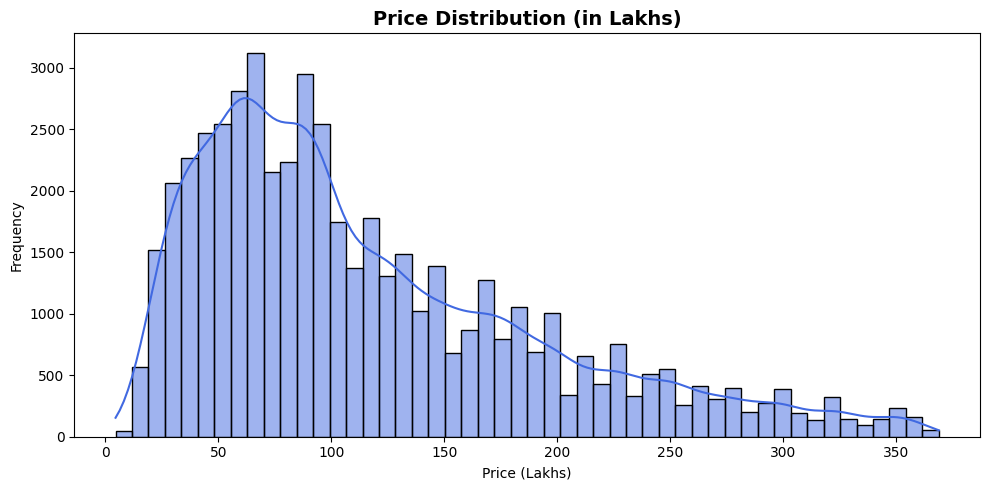

In [17]:
# Price Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price_lakh'], bins=50, kde=True, color='royalblue')
plt.title('Price Distribution (in Lakhs)', fontsize=14, fontweight='bold')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

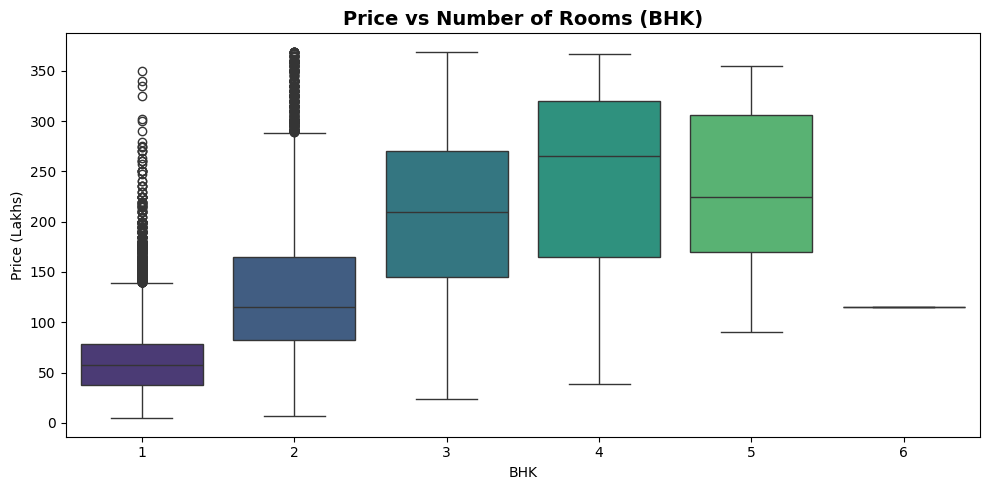

In [18]:
# Price vs BHK
plt.figure(figsize=(10, 5))
sns.boxplot(x='bhk', y='price_lakh', data=df, palette='viridis')
plt.title('Price vs Number of Rooms (BHK)', fontsize=14, fontweight='bold')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.tight_layout()
plt.show()

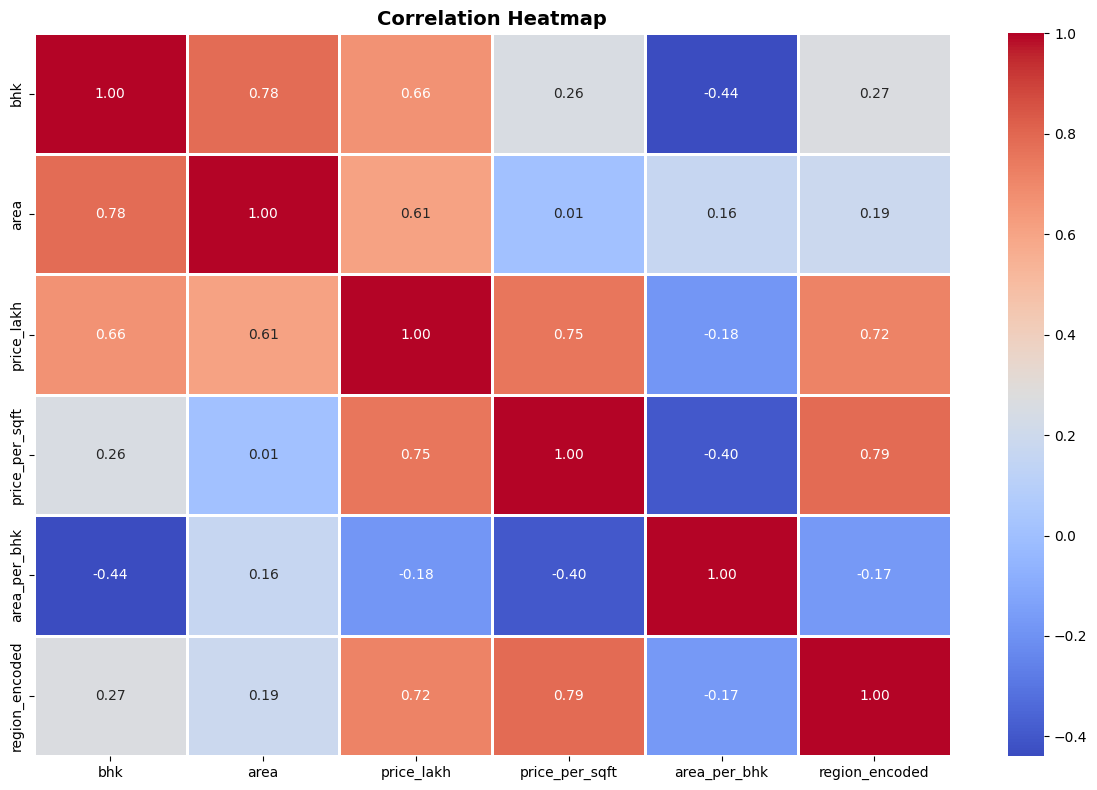

Key correlations with price_lakh:
price_per_sqft    0.753658
region_encoded    0.717404
bhk               0.664932
area              0.607868
area_per_bhk     -0.184594


In [19]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in ['log_price']:
    if c in numeric_cols:
        numeric_cols.remove(c)
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Key correlations with price_lakh:')
corr_with_price = corr['price_lakh'].drop('price_lakh').sort_values(ascending=False)
print(corr_with_price.to_string())

## Task 4 - Implement a Linear Regression Model

- **Outlier removal**: IQR on price, 99th percentile cap on area
- **Target encoding**: region encoded as smoothed mean price
- **One-hot encoding**: type, status, age
- **Log transform**: target variable (price_lakh)
- **New features**: price_per_sqft, area_per_bhk

In [20]:
# Define features (X) and target (y)
feature_cols = [c for c in df.columns if c not in ['price_lakh', 'log_price']]
X = df[feature_cols]
y = df['log_price']   # log-transformed target
print(f'Features (X) shape : {X.shape}')
print(f'Target (y) shape : {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features (X) shape : (51012, 12)
Target (y) shape : (51012,)

Feature columns: ['bhk', 'area', 'price_per_sqft', 'area_per_bhk', 'region_encoded', 'type_Independent House', 'type_Penthouse', 'type_Studio Apartment', 'type_Villa', 'status_Under Construction', 'age_Resale', 'age_Unknown']


## Task 5 - Train the Model

In [26]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Testing set : {X_test.shape[0]:,} samples')

Training set : 40,809 samples
Testing set : 10,203 samples


In [22]:
# Scale features with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model trained successfully')
print(f'\nModel coefficients:')
for feature, coef in zip(X.columns, model.coef_):
    print(f'  {feature:>30s} : {coef:>10.4f}')
print(f'  {"Intercept":>30s} : {model.intercept_:>10.4f}')

Model trained successfully

Model coefficients:
                             bhk :     0.1468
                            area :     0.2485
                  price_per_sqft :     0.4020
                    area_per_bhk :     0.0737
                  region_encoded :     0.1257
          type_Independent House :    -0.0051
                  type_Penthouse :     0.0001
           type_Studio Apartment :    -0.0358
                      type_Villa :    -0.0131
       status_Under Construction :     0.0066
                      age_Resale :     0.0093
                     age_Unknown :    -0.0103
                       Intercept :     4.5506


## Task 6 - Predict House Prices

In [23]:
# Prediction on the test set
y_pred_log = model.predict(X_test_scaled)
# Back-transform from log scale to original Lakhs
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
# Showing a comparison of first 10 actual vs predicted prices
comparison = pd.DataFrame({
    'Actual Price (Lakhs)': np.round(y_test_actual.values[:10], 2),
    'Predicted Price (Lakhs)': np.round(y_pred_actual[:10], 2),
    'Difference': np.round(y_test_actual.values[:10] - y_pred_actual[:10], 2)
})
print('First 10 Predictions vs Actual:')
comparison

First 10 Predictions vs Actual:


,Actual Price (Lakhs),Predicted Price (Lakhs),Difference
0,29.50,54.80,-25.30
1,59.00,54.56,4.44
2,100.00,103.56,-3.56
3,86.87,83.28,3.59
4,177.00,309.33,-132.33
5,24.05,38.19,-14.14
6,78.00,85.40,-7.40
7,124.00,109.21,14.79
8,78.90,71.00,7.90
9,80.00,76.86,3.14


## Task 7 - Evaluate the Model (MSE)

In [24]:
# Calculate evaluation metrics (on original un-logged scale)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)
# Training score for comparison
y_train_pred_log = model.predict(X_train_scaled)
y_train_pred_actual = np.expm1(y_train_pred_log)
y_train_actual = np.expm1(y_train)
r2_train = r2_score(y_train_actual, y_train_pred_actual)
# Cross-validation
cv_scores = cross_val_score(model, scaler.transform(X), y, cv=5, scoring='r2')

print('MODEL EVALUATION RESULTS')
print('')
print(f'Mean Squared Error (MSE): {mse:,.2f}')
print(f'Root MSE (RMSE): {rmse:,.2f} Lakhs')
print(f'Mean Absolute Error (MAE): {mae:,.2f} Lakhs')
print(f'R2 Score (Train): {r2_train:.4f}')
print(f'R2 Score (Test): {r2:.4f}')
print(f'5-Fold Cross-Val R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

MODEL EVALUATION RESULTS

Mean Squared Error (MSE): 611.45
Root MSE (RMSE): 24.73 Lakhs
Mean Absolute Error (MAE): 13.92 Lakhs
R2 Score (Train): 0.8842
R2 Score (Test): 0.8964
5-Fold Cross-Val R2: 0.9434 +/- 0.0045


## Task 8 - Visualize Actual vs Predicted Prices

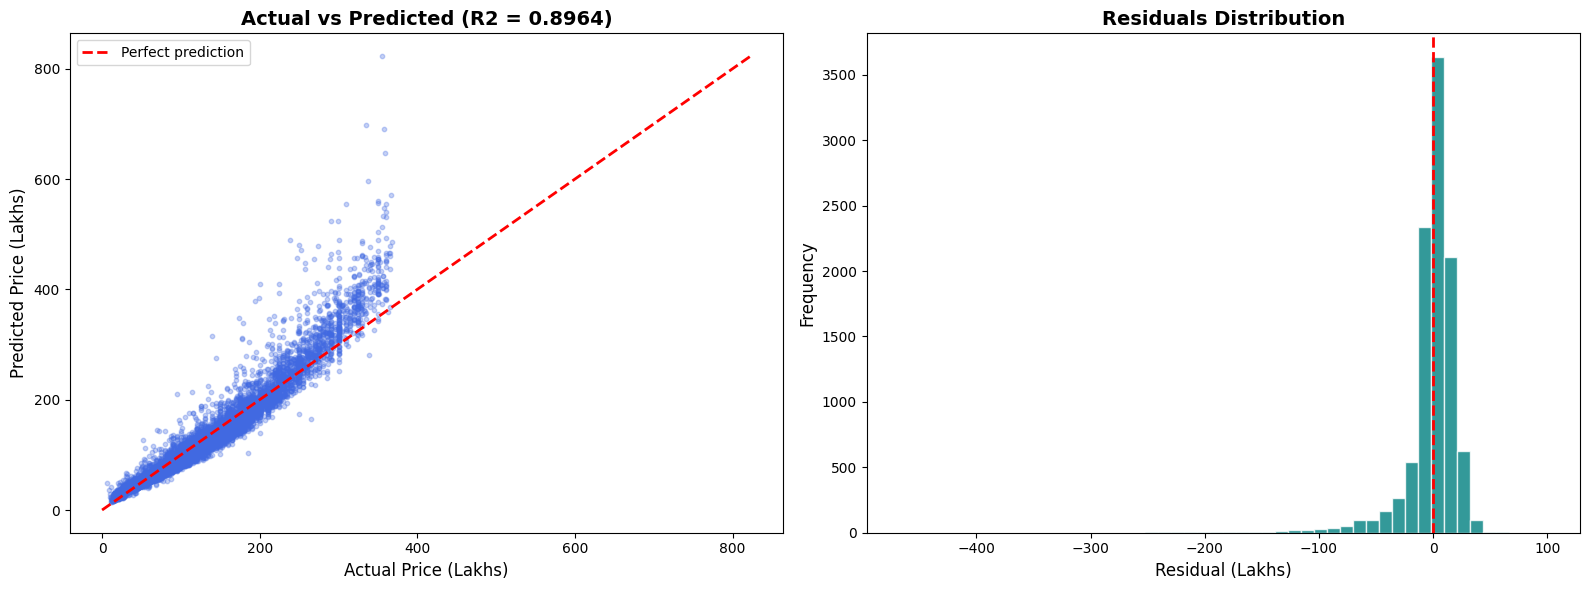

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Actual vs Predicted scatter
ax1 = axes[0]
ax1.scatter(y_test_actual, y_pred_actual, alpha=0.3, s=10, color='royalblue')
max_val = max(y_test_actual.max(), y_pred_actual.max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Price (Lakhs)', fontsize=12)
ax1.set_ylabel('Predicted Price (Lakhs)', fontsize=12)
ax1.set_title(f'Actual vs Predicted (R2 = {r2:.4f})', fontsize=14, fontweight='bold')
ax1.legend()
# Residuals distribution
ax2 = axes[1]
residuals = y_test_actual.values - y_pred_actual
ax2.hist(residuals, bins=50, color='teal', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual (Lakhs)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residuals Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()